<a href="https://colab.research.google.com/github/Vishakha0534/Minor---Smart-campus-AI/blob/main/Copy_of_Image_to_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openai pillow matplotlib -q

In [ ]:
from google.colab import userdata
userdata.get('secretName')

Saving ChatGPT Image May 13, 2026, 11_36_53 AM.png to ChatGPT Image May 13, 2026, 11_36_53 AM.png


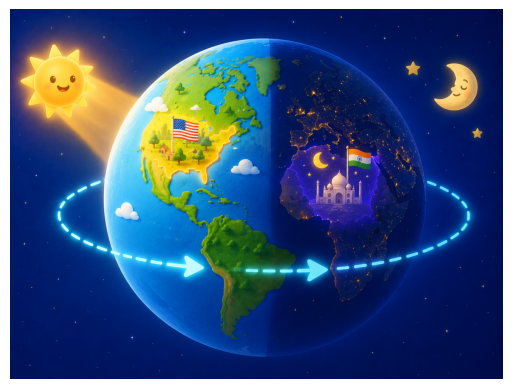

You: What is this image
AI: This image is a cartoon-style illustration of the Earth, divided into two halves: one depicting daytime with the sun, and the other nighttime with the moon and stars. The daytime side shows North and South America with an American flag and green landscapes, while the nighttime side features India with a flag and a mosque, set against a dark, starry sky. The image also includes a dashed line with arrows, suggesting a concept of movement or transition between day and night across the globe.
You: where is the sun
AI: The sun is on the left side of the image, shining over North America.
You: where is india
AI: India is located in South Asia, on the southern part of the Asian continent. It is a large country with a diverse landscape, bordered by Pakistan to the northwest, China and Nepal to the north, Bhutan to the northeast, and Bangladesh and Myanmar to the east. To the south, it is bounded by the Indian Ocean. In the image, India is represented by the flag and

In [ ]:
from google.colab import files
from openai import OpenAI
from PIL import Image
import matplotlib.pyplot as plt
import base64

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Display uploaded image
img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

# Convert image to base64
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

# OpenAI client
client = OpenAI(
    api_key="",
    base_url="https://apidev.navigatelabsai.com"
)

# Continuous chat loop
while True:
    prompt = input("You: ")

    # Stop condition
    if prompt.lower() in ["exit", "quit"]:
        print("Chat ended.")
        break

    # Send request
    response = client.chat.completions.create(
        model="gpt-4.1-nano",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{image_base64}"
                        }
                    }
                ]
            }
        ]
    )

    print("AI:", response.choices[0].message.content)